In [1]:
import os
import random
import IPython
import functools
# import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from pathlib import Path

# Import torch
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch.backends.cudnn as cudnn


# Check that we are using a GPU, if not switch runtimes
#   using Runtime > Change Runtime Type > GPU
if torch.cuda.is_available():
    device = torch.device("cuda")
    cudnn.benchmark = True
else:
  raise ValueError("GPU is not available. Change Colab runtime.")

This is for the new planned trin data (CelebA+CIFAR10)

In [5]:
# from torchvision import datasets, transforms
# from torch.utils.data import DataLoader, ConcatDataset, random_split
# import torch

# transform = transforms.Compose([
#     transforms.Resize((64,64)),
#     transforms.ToTensor()
# ])

# # Positive samples (faces)
# celebA = datasets.CelebA(
#     root='./data',
#     split='train',
#     download=True,
#     transform=transform
# )

# # Negative samples (non-faces)
# cifar_10 = datasets.CIFAR10(
#     root='./data',
#     train=True,
#     download=True,
#     transform=transform
# )
# cifar_10.targets = [0] * len(cifar_10)



In [ ]:
# MIT introduction to deep learning package
# %pip install mitdeeplearning --quiet
import mitdeeplearning as mdl

In [6]:
CACHE_DIR = Path.home() / ".cache" / "face"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# Get the training data: both images from CelebA and ImageNet
path_to_training_data = CACHE_DIR.joinpath("train_face.h5")

# Create a simple check to avoid re-downloading
if path_to_training_data.is_file():
    print(f"Using cached training data from {path_to_training_data}")
else:
    print(f"Downloading training data to {path_to_training_data}")
    url = "https://www.dropbox.com/s/hlz8atheyozp1yx/train_face.h5?dl=1"
    torch.hub.download_url_to_file(url, path_to_training_data)


100%|██████████| 1.18G/1.18G [01:12<00:00, 17.4MB/s]


In [167]:
import h5py
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch
from torch.utils.data import Subset
from torch.utils.data import DataLoader

class H5FaceDataset(Dataset):
    def __init__(self, h5_path, transform=None, channels_last=False):
        self.file = h5py.File(h5_path, "r")
        self.images = self.file["images"]
        self.labels = self.file["labels"] if "labels" in self.file else None
        self.transform = transform
        self.channels_last = channels_last

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        if not self.channels_last:
            # convert from HWC → CHW
            img = img.transpose(2, 0, 1)

        img = torch.tensor(img, dtype=torch.float32) / 255.0  # normalize to [0,1]
        
        if self.labels is not None:
            label = torch.tensor(self.labels[idx], dtype=torch.long)
            return img, label
        else:
            return img

# Now, create a single transform that includes Resize
# Note: apply Resize *after* the tensor is created and normalized [0,1]
# add antialias=True to match modern PyTorch defaults.
transform = transforms.Compose([
    transforms.Resize((64,64), antialias=True), 
])

# Create a simple wrapper dataset to apply the transform *after* subsetting
class TransformedSubset(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
    def __getitem__(self, index):
        x, y = self.subset[index]
        return self.transform(x), y
    def __len__(self):
        return len(self.subset)

dataset = H5FaceDataset(path_to_training_data)


In [50]:
import numpy as np
labels = np.array(dataset.labels)
import torch
from collections import Counter
label_counts = Counter(labels.squeeze())
print(label_counts)

Counter({np.uint8(0): 54957, np.uint8(1): 54957})


In [168]:
# Subsample 10k per class

# Get indices for each class
labels = torch.from_numpy(np.array(dataset.labels))  # all labels
class0_indices = torch.where(labels == 0)[0][:2000]  # non-faces
class1_indices = torch.where(labels == 1)[0][:2000]  # faces

# Combine indices
selected_indices = torch.cat([class0_indices, class1_indices])
# shuffle
selected_indices = selected_indices[torch.randperm(len(selected_indices))]


# Split into train/validation (80/20)
# Create a subset dataset
small_dataset = Subset(dataset, selected_indices)

train_size = int(0.8 * len(small_dataset))
valid_size = len(small_dataset) - train_size

train_dataset, valid_dataset = torch.utils.data.random_split(
    small_dataset, [train_size, valid_size],
    generator=torch.Generator().manual_seed(42)
)

# Apply the wrapper to your train/valid subsets
train_dataset_transformed = TransformedSubset(train_dataset, transform)
valid_dataset_transformed = TransformedSubset(valid_dataset, transform)

# Create DataLoaders

batch_size = 32
train_loader = DataLoader(train_dataset_transformed, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset_transformed, batch_size=batch_size, shuffle=False)

In [169]:
len(train_loader), len(valid_loader)

(100, 25)

In [69]:
# Get first batch
images, labels = next(iter(train_loader))

# Check shapes
print("Images shape:", images.shape)  # [batch_size, channels, height, width]
print("Labels shape:", labels.shape)

Images shape: torch.Size([32, 3, 32, 32])
Labels shape: torch.Size([32, 1])


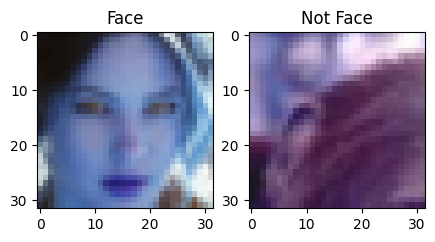

In [83]:
# Dislay images
### Examining the CelebA training dataset ###
import matplotlib.pyplot as plt

face_images = images[np.where(labels == 1)[0]].permute(0, 2, 3, 1)
not_face_images = images[np.where(labels== 0)[0]].permute(0, 2, 3, 1)
idx_face = 10
idx_not_face = 7
plt.figure(figsize=(5, 5))
plt.subplot(1, 2, 1)

if len(face_images) > 0:
    plt.imshow(face_images[idx_face])
    plt.title("Face")
else:
    plt.title("No Face images in batch")

plt.grid(False)

plt.subplot(1, 2, 2)
if len(not_face_images) > 0:
    plt.imshow(not_face_images[idx_not_face])
    plt.title("Not Face")
else:
    plt.title("No Not Face images in batch")
plt.grid(False)

In [170]:
class Face_CNN(nn.Module):
  def __init__(self):
    super().__init__()
    # Build the layers
    # Block 1 
    self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3,stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2))
    
    self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 *4 *4, 256),
            nn.ReLU(),
            nn.Linear(256, 1)
        )
  def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x
    

check_model = Face_CNN()
print(check_model)

Face_CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(

In [171]:
images, labels = next(iter(train_loader))
dummy = images[0].to(device).unsqueeze(0)
dummy.shape


torch.Size([1, 3, 64, 64])

In [172]:
check_model.to(device)
output = check_model(dummy)
print(check_model)

Face_CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(

# Train and test the CNN model

In [173]:
from prompt_toolkit import history
from torchvision.io.video import av

class Trainer:
  def __init__(self, model, optimizer, loss_function, device=None):
    self.loss_function = loss_function
    self.optimizer = optimizer
    self.device = device if device else torch.device("cuda" if torch.cuda.is_available() else "cpu")
    self.model = model
    self.model.to(self.device)
    print(f"Trainer Object Initialized on Device: {self.device}")

  def _train_epoch(self, train_loader, verbose=False):
    """Internal Training method for a epoch

      return traing loss, training accuracy for one epoch
    """
    self.model.train() # Set the model in training mode

    correct, total = 0, 0
    training_loss = []

    loop = tqdm(train_loader, desc="Training", leave = False) if verbose else train_loader
    # Training loop
    for x_batch, y_batch in loop:
      x_batch, y_batch = x_batch.to(self.device), y_batch.to(self.device)

      # Forward pass
      outputs = self.model(x_batch)
      self.model.zero_grad()

      # Calculate loss and accuracy
      loss = self.loss_function(outputs.squeeze(), y_batch.float().squeeze()) # Cast y_batch to float and squeeze
      loss.backward()
      self.optimizer.step()
      training_loss.append(loss.item())

      total += len(x_batch)
      predicted = (torch.sigmoid(outputs) > 0.5).long().squeeze() # Correct prediction for BCEWithLogitsLoss
      correct += (predicted == y_batch.squeeze()).sum().item()

      if verbose:
        loop.set_postfix(loss=loss.item(), accuracy=100* correct/total)

    avg_train_loss = np.mean(training_loss)
    train_accuracy = correct / total * 100
    return avg_train_loss, train_accuracy

  def _validate_epoch(self, valid_loader, verbose=False,  return_probs=False):
      """ Internal Validation method for a epoch

      return validation loss, validation accuracy for one epoch
      """

      self.model.eval() # Set the model in evaluation mode
      all_probs = []  # To store probabilities if needed
      correct, total = 0, 0
      validation_loss = []
      loop = tqdm(valid_loader, desc="Validation", leave = False) if verbose else valid_loader

      for x_val, y_val in loop:
        x_val, y_val = x_val.to(self.device), y_val.to(self.device)
        with torch.no_grad():
          outputs = self.model(x_val)
          loss = self.loss_function(outputs.squeeze(), y_val.float().squeeze()) # Cast y_val to float and squeeze
          validation_loss.append(loss.item())
          # Store probabilities if needed
          probs = torch.sigmoid(outputs).squeeze()
          if return_probs:
                all_probs.append(probs.cpu())

          total += len(x_val)
          predicted = (torch.sigmoid(outputs) > 0.5).long().squeeze() # Correct prediction for BCEWithLogitsLoss
          correct += (predicted == y_val.squeeze()).sum().item()
          if verbose:
            loop.set_postfix(loss=loss.item(), accuracy=100* correct/total)

      avg_val_loss = np.mean(validation_loss)
      val_accuracy = correct / total * 100
      
      if return_probs:
        return avg_val_loss, val_accuracy, torch.cat(all_probs, dim=0)
    
      return avg_val_loss, val_accuracy

  def fit(self, train_loader, validation_loader, epochs=10, verbose=True):
      """Trains and evaluates the model for a specified number of epochs."""
      history = {
              "train_accuracy": [],
              "train_loss": [],
              "val_accuracy": [],
              "val_loss": []
          }

      for epoch in range(epochs):
        # Training and validation for one epoch
        train_loss, train_acc = self._train_epoch(train_loader, verbose=verbose)
        val_loss, val_acc = self._validate_epoch(validation_loader, verbose=verbose)

        # Store history
        history['train_loss'].append(train_loss)
        history['train_accuracy'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_acc)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%"
            )
      return history

  def test(self, test_loader, verbose=True):
        """
        Evaluates the model on the test set after training.
        """
        print("\nEvaluating on the test set...")
        avg_test_loss, test_accuracy = self._validate_epoch(test_loader, verbose=verbose)
        print(f"--> Test Loss: {avg_test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%")
        return avg_test_loss, test_accuracy

In [174]:
model = Face_CNN()
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.NAdam(model.parameters(), lr=1e-3)
trainer = Trainer(model,optimizer,loss_fn)

history = trainer.fit(
    epochs=1,
    train_loader=train_loader,
    validation_loader=valid_loader
)

Trainer Object Initialized on Device: cuda


Epoch 1/1 | Train Loss: 0.1230, Train Acc: 94.94% | Val Loss: 0.1887, Val Acc: 93.88%


In [188]:
# Train
# history = trainer.fit(
#     epochs=1,
#     train_loader=train_loader,
#     validation_loader=valid_loader
# )

# ---- SAVE CHECKPOINT HERE ----
torch.save({
    "epoch": 1,
    "model_state": model.state_dict(),
    "optimizer_state": optimizer.state_dict(),
    "history": history
}, "checkpoint.pth")

print("Checkpoint saved.")


Checkpoint saved.


In [189]:
checkpoint = torch.load("checkpoint.pth", map_location=device, weights_only=False)

model.load_state_dict(checkpoint["model_state"])
optimizer.load_state_dict(checkpoint["optimizer_state"])

start_epoch = checkpoint["epoch"]

print(f"Loaded checkpoint. Resuming from epoch {start_epoch}.")


Loaded checkpoint. Resuming from epoch 1.


### Enable this to continue the training again

In [ ]:
# history = trainer.fit(
#     epochs=5 - start_epoch,
#     train_loader=train_loader,
#     validation_loader=valid_loader
# )


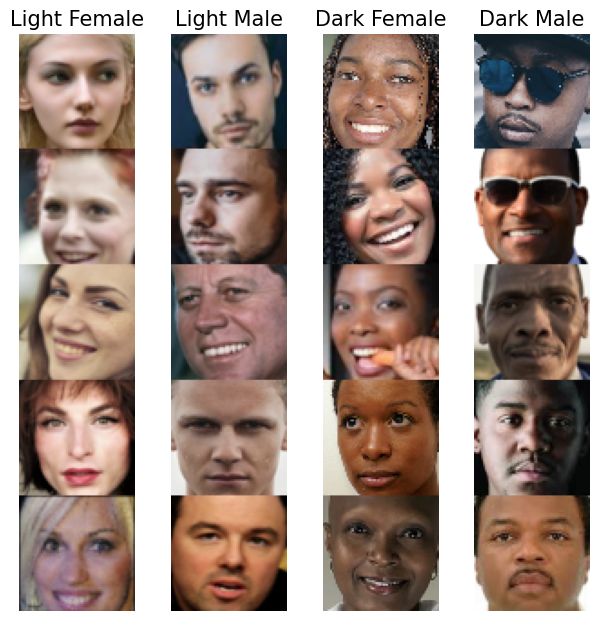

In [175]:
### Load test dataset and plot examples ###

channels_last = False  # Set to False for CHW format (PyTorch default), True for HWC format
test_faces = mdl.lab2.get_test_faces(channels_last=channels_last)
keys = ["Light Female", "Light Male", "Dark Female", "Dark Male"]

fig, axs = plt.subplots(1, len(keys), figsize=(7.5, 7.5))
for i, (group, key) in enumerate(zip(test_faces, keys)):
    axs[i].imshow(np.hstack(group).transpose(1, 2, 0))
    axs[i].set_title(key, fontsize=15)
    axs[i].axis("off")

In [157]:
test_faces

([array([[[0.66666667, 0.63529412, 0.63529412, ..., 0.66666667,
           0.70588235, 0.74901961],
          [0.62352941, 0.59607843, 0.61176471, ..., 0.64705882,
           0.68235294, 0.74509804],
          [0.59607843, 0.6       , 0.62745098, ..., 0.66666667,
           0.68235294, 0.74509804],
          ...,
          [0.65882353, 0.56078431, 0.61176471, ..., 0.53333333,
           0.52941176, 0.60784314],
          [0.6627451 , 0.57647059, 0.61176471, ..., 0.55686275,
           0.5372549 , 0.61960784],
          [0.63529412, 0.56862745, 0.56078431, ..., 0.56078431,
           0.55686275, 0.6       ]],
  
         [[0.60392157, 0.56470588, 0.55686275, ..., 0.61568627,
           0.66666667, 0.71764706],
          [0.54901961, 0.51764706, 0.53333333, ..., 0.59215686,
           0.63921569, 0.70980392],
          [0.52156863, 0.5254902 , 0.55294118, ..., 0.6       ,
           0.63529412, 0.70980392],
          ...,
          [0.55294118, 0.4627451 , 0.52156863, ..., 0.41960784,
  

In [ ]:
for x in test_faces:            
    print(torch.tensor(x).shape)

torch.Size([5, 3, 64, 64])
torch.Size([5, 3, 64, 64])
torch.Size([5, 3, 64, 64])
torch.Size([5, 3, 64, 64])


In [134]:
test_faces_dict = {}
for (x, key) in zip(test_faces, keys):
    x  = torch.tensor(x, dtype=torch.float32).to(device)
    test_faces_dict[key] = F.interpolate(x, size=(32, 32), mode='bilinear', align_corners=False)
    


Category: Light Female
  Image 1: True, Probability: 0.6963
  Image 2: True, Probability: 0.6481
  Image 3: True, Probability: 0.6293
  Image 4: True, Probability: 0.7125
  Image 5: True, Probability: 0.6124
Category: Light Male
  Image 1: True, Probability: 0.6832
  Image 2: True, Probability: 0.6678
  Image 3: True, Probability: 0.6221
  Image 4: True, Probability: 0.6735
  Image 5: True, Probability: 0.6785
Category: Dark Female
  Image 1: True, Probability: 0.6838
  Image 2: True, Probability: 0.6785
  Image 3: True, Probability: 0.6007
  Image 4: True, Probability: 0.6351
  Image 5: True, Probability: 0.5818
Category: Dark Male
  Image 1: True, Probability: 0.6049
  Image 2: True, Probability: 0.7445
  Image 3: True, Probability: 0.6054
  Image 4: True, Probability: 0.6450
  Image 5: True, Probability: 0.6460


Text(0.5, 1.0, 'Standard classifier predictions')

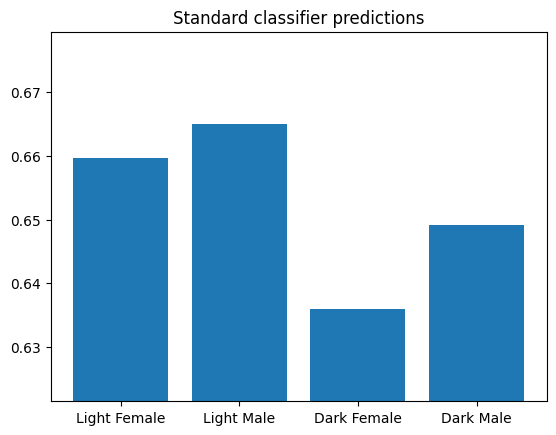

In [187]:
import torch
import torch.nn.functional as F

# Assume test_faces is a list of arrays, each [5,3,64,64]
# keys = ["Light Female", "Light Male", "Dark Female", "Dark Male"]

test_faces_dict = {}
for (x, key) in zip(test_faces, keys):
    x_tensor = torch.tensor(x, dtype=torch.float32).to(device)

    # *** USE THIS INSTEAD OF F.interpolate ***
    x_transformed = transform(x_tensor) 

    test_faces_dict[key] = x_transformed
    
standard_classifier_probs_list = []
# Now run through the model category by category
for key, imgs in test_faces_dict.items():
    with torch.no_grad():
        outputs = check_model(imgs)           # imgs shape: [5,3,32,32]
        probs = torch.sigmoid(outputs)
        preds =  preds > 0.5
        mean_prob_for_category = probs.mean().item() 
        standard_classifier_probs_list.append(mean_prob_for_category)
    print(f"Category: {key}")
    for i, p in enumerate(preds):
        print(f"  Image {i+1}: {p.item()}, Probability: {torch.sigmoid(outputs[i]).item():.4f}")
        
# Plot the prediction accuracies per demographic
standard_classifier_probs = np.array(standard_classifier_probs_list)  # shape [4]
xx = range(len(keys))
yy = standard_classifier_probs  # Already aggregated per category
plt.bar(xx, yy)
plt.xticks(xx, keys)
plt.ylim(max(0, yy.min() - np.ptp(yy) / 2.0), yy.max() + np.ptp(yy) / 2.0)
plt.title("Standard classifier predictions")


TypeError: 'float' object is not subscriptable

Text(0.5, 1.0, 'Standard classifier predictions')

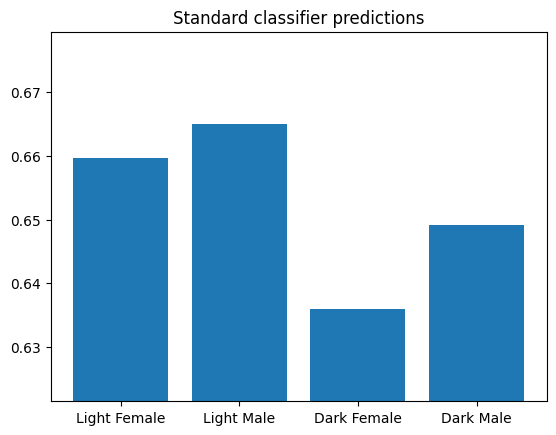

In [190]:
# Plot the prediction accuracies per demographic
standard_classifier_probs = np.array(standard_classifier_probs_list)  # shape [4]
xx = range(len(keys))
yy = standard_classifier_probs  # Already aggregated per category
plt.bar(xx, yy)
plt.xticks(xx, keys)
plt.ylim(max(0, yy.min() - np.ptp(yy) / 2.0), yy.max() + np.ptp(yy) / 2.0)
plt.title("Standard classifier predictions")